# 8)
First we plot the histogram of the sum of 3 lognormal random variables.

Text(0, 0.5, 'Density')

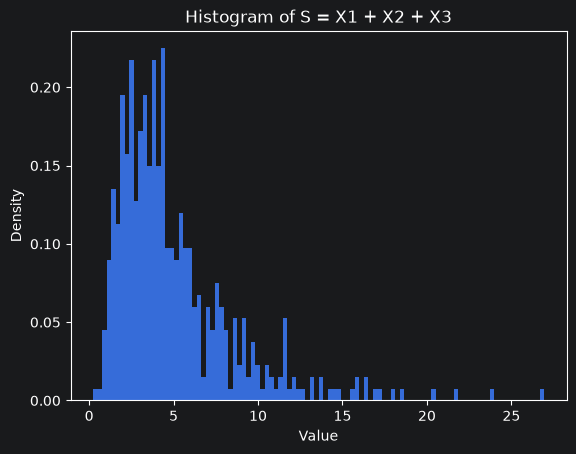

In [15]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
N = 500

def create_s_sample(m = 3):
    # Function that returns sum of m lognormal random variables
    z = np.random.normal(0, 1, m)
    x = np.exp(z)
    return np.sum(x)

# Create N samples
samples = [create_s_sample() for _ in range(N)]

# Plot histogram of the samples
plt.hist(samples, bins=100, density=True)
plt.title("Histogram of S = X1 + X2 + X3")
plt.xlabel("Value")
plt.ylabel("Density")

We then estimate the probability the $P( S > x)$

Text(0, 0.5, 'Estimated Probability')

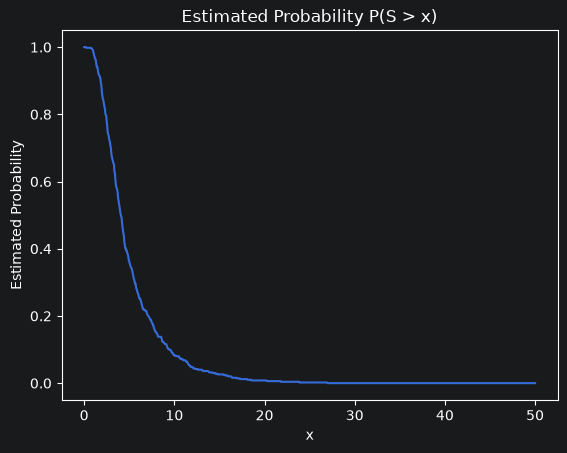

In [16]:
def estimate_probability(samples, x):
    # Function that estimates the probability P(S > x)
    count = np.sum(np.array(samples) > x)
    return count / len(samples)
x = np.linspace(0, 50, 1000)
estimated_probabilties = [estimate_probability(samples, xi) for xi in x]
plt.plot(x, estimated_probabilties)
plt.title("Estimated Probability P(S > x)")
plt.xlabel("x")
plt.ylabel("Estimated Probability")

We note that each estimate is a random variable, and thus we can construct estimate confidence intervals. Note that if we define an indicator function $I_i = 1$ if $S_i > x$ and $0$ and write the estimated probability as
$$
\hat{p} = \frac{1}{N} \sum_{i=1}^{N} I_i
$$
Then we get a sum of N iid Bernoulli random variables, thus a Binomial(N, p) random variable. We can then estimate the variance of the estimated probability as
$$
Var[p] = \dfrac{1}{N^2}Var[X] = \frac{p(1-p)}{N}
$$
where X is a Binomial(N, p) random variable. We can thereby estimate the standard deviation of the estimated probability as
$$
SE(\hat{p}) \approx \sqrt{\frac{\hat{p}(1-\hat{p})}{N}}
$$

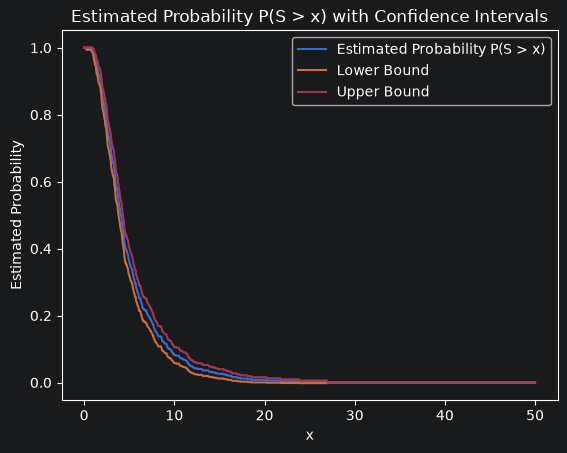

In [17]:
def estimate_confidence_interval(samples, x, alpha = 0.05):
    # Function that estimates the confidence interval for P(S > x)
    p_hat = estimate_probability(samples, x)
    se = np.sqrt(p_hat * (1 - p_hat) / len(samples))
    z = norm.ppf(1 - alpha / 2)
    lower_bound = p_hat - z * se
    upper_bound = p_hat + z * se
    return lower_bound, upper_bound
# Compute for all x values
bounds = [estimate_confidence_interval(samples, xi) for xi in x]
lower_bounds, upper_bounds = zip(*bounds)
# Plot the estimated probabilities with confidence intervals
plt.plot(x, estimated_probabilties, label="Estimated Probability P(S > x)")
plt.plot(x, lower_bounds, label="Lower Bound")
plt.plot(x, upper_bounds, label="Upper Bound")
plt.title("Estimated Probability P(S > x) with Confidence Intervals")
plt.xlabel("x")
plt.ylabel("Estimated Probability")
plt.legend()
